### -cleaning data from nans

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
#1
titanic=pd.read_csv(r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\week2\day5\tested.csv")
print(titanic.isnull().sum())
titanic.drop(columns="Cabin",inplace=True)#اخترت الحذف لانو رقم الكبينه او الغرفه مش راح يفرق على الدراسة باشي ولانو اكثر من نصو فاضي صعب نعبيه
titanic['Age']=titanic['Age'].fillna(titanic['Age'].mean())
titanic['Fare']=titanic['Fare'].fillna(titanic['Fare'].median())
print(titanic.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### 1. Descriptive Statistics

In [8]:
titanic.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.576535
std,120.810458,0.481622,0.841838,12.634534,0.896760,0.981429,55.850103
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,30.272590,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,35.750000,1.000000,0.000000,31.471875
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [9]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         418 non-null    float64
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 36.1 KB


### 2.  univariate

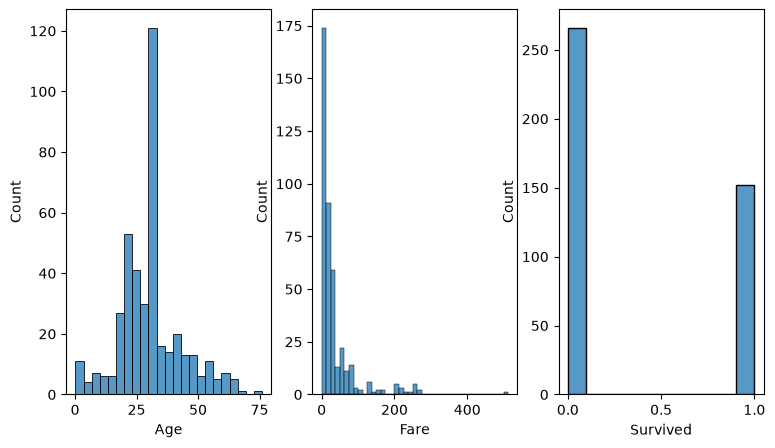

In [10]:
df=titanic[['Survived','Name', 'Sex', 'Age',
         'Fare','Embarked']]
fig,axis=plt.subplots(1,3, figsize=(9,5))
sns.histplot(data=df,x='Age',ax=axis[0])
axis[0].set_tilte="age"
sns.histplot(data=df,x='Fare',ax=axis[1])
axis[1].set_tilte="fare"
sns.histplot(data=df,x='Survived',ax=axis[2])
axis[2].set_tilte="survived"
plt.show()


***Age Distribution***

- Most passengers were young adults.

- The distribution is slightly right-skewed.

- There are some missing values in the Age column.


***Fare Distribution***

- The Fare distribution is highly right-skewed.
- Most passengers paid low ticket prices.
- A few passengers paid very expensive fares.

 ### 3.outliers

In [11]:
q1=df['Fare'].quantile(0.25)
q3=df['Fare'].quantile(0.75)
IQR=q3-q1
outliers=df[(df['Fare']<q1-IQR*1.5)|(df['Fare']>q3+IQR*1.5)]
print(len(outliers))

55


**Outlier Handling**

**The IQR method detected several outliers in the Fare column.**

**These outliers were kept because they represent real passengers who paid expensive ticket prices rather than data entry errors.**

**Removing them could result in losing valuable information.**

### step 1

-1 The scatter plot of Age vs. Fare shows a slight positive relationship, indicating that Fare tends to increase slightly with Age, but the overall correlation is weak.

<Axes: xlabel='Age', ylabel='Fare'>

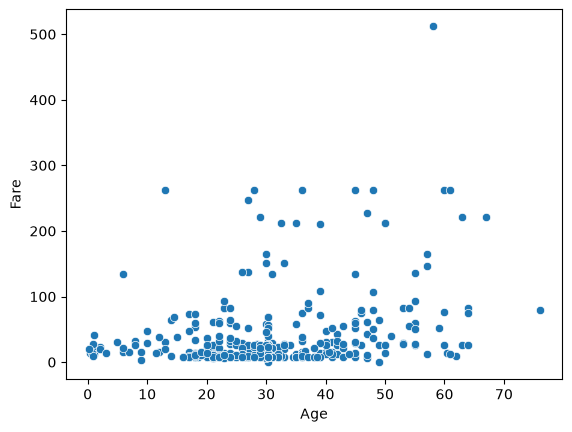

In [2]:
sns.scatterplot(data=titanic,x='Age',y='Fare')

-2 A grouped box plot of Embarked vs. Fare illustrates the price distribution across different departure ports. Passengers embarking from Port Cherbourg (C) generally paid higher fares compared to those who embarked from Southampton (S) or Queenstown (Q).

<Axes: xlabel='Embarked', ylabel='Fare'>

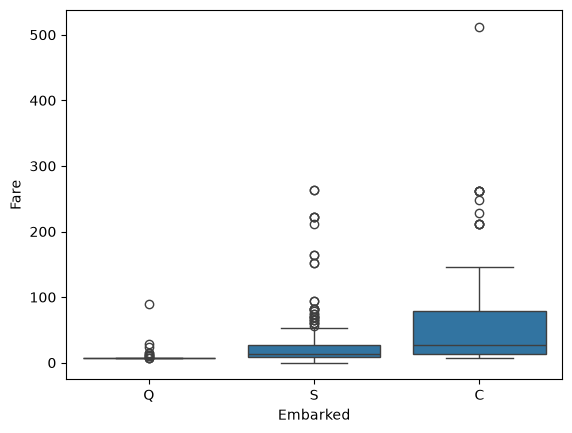

In [3]:
sns.boxplot(data=titanic,x='Embarked',y='Fare')

### step 2


-1 The heatmap highlights two key relationships among numerical variables:

Pclass vs. Fare (Strong Negative Correlation): Lower class numbers (First Class = 1) correspond to significantly higher fares.

Age vs. Fare (Slight Positive Correlation): Fares show a mild increase as passenger age increases.

<Axes: >

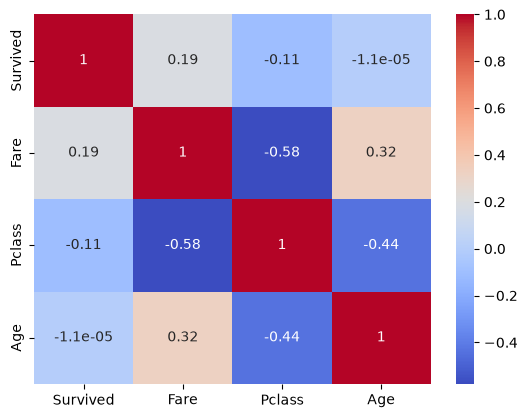

In [6]:
corr=titanic[['Survived','Fare','Pclass','Age']].corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')